# 02 — Exploratory Data Analysis

**Purpose.** Profile the corpus before any text is modified. Three questions
drive the analysis, and each one feeds a decision made later:

1. **How imbalanced are the labels?** — decides whether a weighted loss is needed.
2. **What noise does the text carry?** — decides which preprocessing stages are justified.
3. **How many tweets actually contain emoji?** — this is the ceiling on any emoji
   effect the study can possibly measure, so it bounds the interpretation of every
   later result.

| | |
|---|---|
| **Input**  | `data/interim/{train,dev,test}_raw.csv` |
| **Output** | figures in `figures/`, summary tables in `results/` |
| **Next**   | `03_model_train.ipynb` |

In [1]:
import os
from pathlib import Path

ON_KAGGLE = os.path.exists("/kaggle/working")

if ON_KAGGLE:
    PROJECT = Path("/kaggle/working")
    RAW_CANDIDATES = [Path("/kaggle/input")]
else:
    # notebooks/ lives one level below the project root
    PROJECT = Path.cwd()
    if PROJECT.name == "notebooks":
        PROJECT = PROJECT.parent
    RAW_CANDIDATES = [PROJECT / "data" / "raw"]

INTERIM   = PROJECT / "data" / "interim"
PROCESSED = PROJECT / "data" / "processed"
MODELS    = PROJECT / "models"
RESULTS   = PROJECT / "results"
FIGURES   = PROJECT / "figures"
for d in (INTERIM, PROCESSED, MODELS, RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

EMOTION_LABELS = [
    "anger", "anticipation", "disgust", "fear", "joy", "love",
    "optimism", "pessimism", "sadness", "surprise", "trust",
]
TRACKS = [
    ("no_emoji",   "text_no_emoji",   "Without Emoji"),
    ("with_emoji", "text_with_emoji", "With Emoji"),
]

print("project root :", PROJECT)
print("on kaggle    :", ON_KAGGLE)

project root : /Users/krishkrish/Documents/AI Projects/Dissertation/krish
on kaggle    : False


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
BLUE, RUST = "#3B6EA5", "#B3512F"

train = pd.read_csv(INTERIM / "train_raw.csv")
dev   = pd.read_csv(INTERIM / "dev_raw.csv")
test  = pd.read_csv(INTERIM / "test_raw.csv")

splits = {"train": train, "dev": dev, "test": test}
print({k: len(v) for k, v in splits.items()})

{'train': 6838, 'dev': 886, 'test': 3259}


## 2.1 Split sizes

In [3]:
sizes = pd.DataFrame([
    {"split": k, "tweets": len(v), "share %": round(100 * len(v) / sum(map(len, splits.values())), 1)}
    for k, v in splits.items()
])
display(sizes)

,split,tweets,share %
0,train,6838,62.3
1,dev,886,8.1
2,test,3259,29.7


## 2.2 Label distribution

The single most consequential property of this corpus. If the ratio between the
most and least frequent emotion is large, an unweighted objective will be
minimised most efficiently by simply never predicting the rare classes.

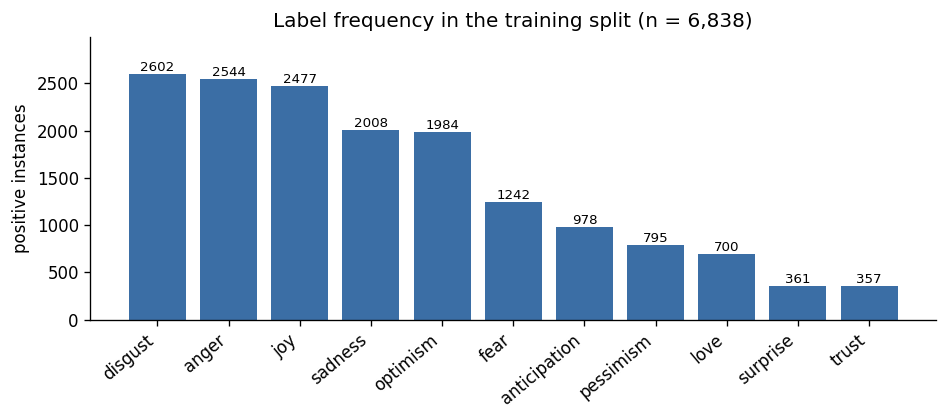

most frequent : disgust (2602)
least frequent: trust (357)
imbalance ratio: 7.3 : 1

-> severe imbalance: a class-weighted loss and threshold tuning are justified


In [4]:
counts = train[EMOTION_LABELS].sum().sort_values(ascending=False)
ratio = counts.max() / counts.min()

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(counts.index, counts.values, color=BLUE)
ax.bar_label(bars, fontsize=8)
ax.set_ylabel("positive instances")
ax.set_title(f"Label frequency in the training split (n = {len(train):,})")
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "label_distribution.png")
plt.show()

print(f"most frequent : {counts.index[0]} ({counts.iloc[0]})")
print(f"least frequent: {counts.index[-1]} ({counts.iloc[-1]})")
print(f"imbalance ratio: {ratio:.1f} : 1")
if ratio > 3:
    print("\n-> severe imbalance: a class-weighted loss and threshold tuning are justified")

## 2.3 Multi-label structure

How many emotions does a single tweet carry? If most tweets carry more than one,
the problem is genuinely multi-label and cannot be reduced to single-label
classification.

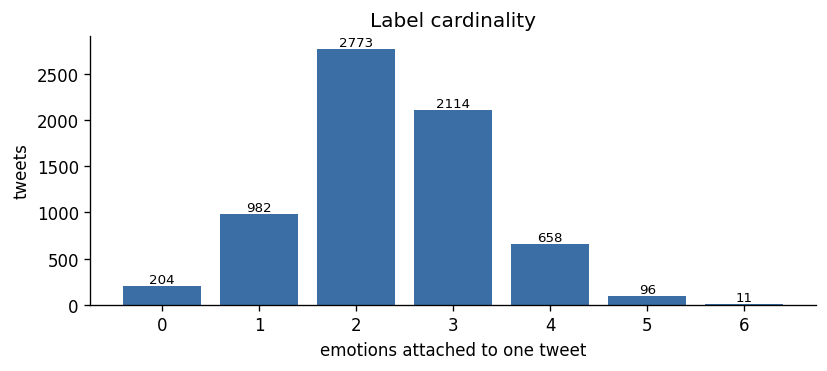

mean labels per tweet : 2.35
tweets with 0 labels  : 204
tweets with 2 or more : 5652 (82.7%)


In [5]:
per_tweet = train[EMOTION_LABELS].sum(axis=1)
dist = per_tweet.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.bar(dist.index.astype(str), dist.values, color=BLUE)
ax.bar_label(bars, fontsize=8)
ax.set_xlabel("emotions attached to one tweet")
ax.set_ylabel("tweets")
ax.set_title("Label cardinality")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "label_cardinality.png")
plt.show()

print(f"mean labels per tweet : {per_tweet.mean():.2f}")
print(f"tweets with 0 labels  : {(per_tweet == 0).sum()}")
print(f"tweets with 2 or more : {(per_tweet >= 2).sum()} "
      f"({100 * (per_tweet >= 2).mean():.1f}%)")

## 2.4 Label co-occurrence

Which emotions travel together? Strong pairs explain confusions that show up later
in the confusion matrices, and they are also the reason an independent per-label
classifier leaves something on the table.

In [6]:
co = pd.DataFrame(
    train[EMOTION_LABELS].T.dot(train[EMOTION_LABELS]),
    index=EMOTION_LABELS, columns=EMOTION_LABELS).astype(float)
norm = co.div(np.diag(co), axis=0)      # P(column | row)
np.fill_diagonal(norm.values, np.nan)

fig, ax = plt.subplots(figsize=(7, 5.8))
im = ax.imshow(norm.values, cmap="Blues", vmin=0, vmax=np.nanmax(norm.values))
ax.set_xticks(range(len(EMOTION_LABELS)), EMOTION_LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(EMOTION_LABELS)), EMOTION_LABELS)
ax.set_title("P(column emotion | row emotion)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIGURES / "label_cooccurrence.png")
plt.show()

pairs = (norm.stack().sort_values(ascending=False).head(6)
           .rename("P(b|a)").reset_index()
           .rename(columns={"level_0": "given a", "level_1": "then b"}))
display(pairs.round(3))

ValueError: underlying array is read-only

## 2.5 What noise does the raw text carry?

Each figure here justifies (or fails to justify) one preprocessing stage.

In [ ]:
t = train["text"].astype(str)
train["text_length"] = t.str.len()
train["word_count"]  = t.str.split().str.len()
train["has_url"]     = t.str.contains(r"http|www\.", regex=True)
train["has_mention"] = t.str.contains(r"@\w+", regex=True)
train["has_hashtag"] = t.str.contains(r"#\w+", regex=True)
train["has_emoji"]   = t.str.contains(r"[\U0001F300-\U0001FAFF]", regex=True)

quality = pd.DataFrame([
    {"property": "mean characters", "value": round(train["text_length"].mean(), 1),
     "justifies": "sequence length of 128 tokens is ample"},
    {"property": "mean words", "value": round(train["word_count"].mean(), 1),
     "justifies": "short texts: every token matters"},
    {"property": "contains a URL", "value": int(train["has_url"].sum()),
     "justifies": "URL stripping"},
    {"property": "contains @mention", "value": int(train["has_mention"].sum()),
     "justifies": "mention stripping + de-identification"},
    {"property": "contains #hashtag", "value": int(train["has_hashtag"].sum()),
     "justifies": "keep the word, drop the # symbol"},
    {"property": "contains emoji", "value": int(train["has_emoji"].sum()),
     "justifies": "the manipulated variable of this study"},
])
quality["% of split"] = (100 * quality["value"] / len(train)).round(1)
display(quality)
quality.to_csv(RESULTS / "eda_text_quality.csv", index=False)

,property,value,justifies,% of split
0,mean characters,95.2,sequence length of 128 tokens is ample,1.4
1,mean words,16.1,short texts: every token matters,0.2
2,contains a URL,0.0,URL stripping,0.0
3,contains @mention,3061.0,mention stripping + de-identification,44.8
4,contains #hashtag,2998.0,"keep the word, drop the # symbol",43.8
5,contains emoji,770.0,the manipulated variable of this study,11.3


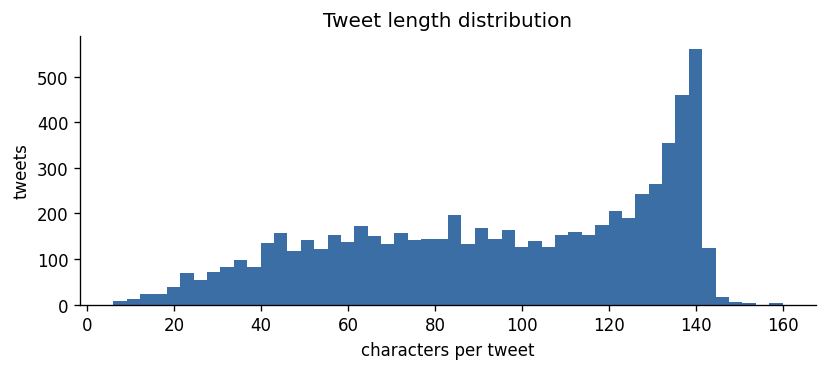

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(train["text_length"], bins=50, color=BLUE)
ax.set_xlabel("characters per tweet")
ax.set_ylabel("tweets")
ax.set_title("Tweet length distribution")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "text_length.png")
plt.show()

## 2.6 Emoji density — the ceiling on the whole study

This is the number that bounds every result in the project. The two preprocessing
tracks differ *only* on tweets that contain at least one emoji; on every other row
they produce byte-identical text. So the share of emoji-bearing tweets caps how
large any aggregate difference between the tracks can possibly be.

In [ ]:
emoji_pct = 100 * train["has_emoji"].mean()

print(f"tweets with emoji : {int(train['has_emoji'].sum()):,} / {len(train):,}"
      f"  ({emoji_pct:.1f}%)")
print(f"tweets identical across both tracks: {100 - emoji_pct:.1f}%")
print()
print("Interpretation: the aggregate difference between the two tracks is diluted")
print(f"by the {100 - emoji_pct:.1f}% of rows the manipulation cannot touch. A small")
print("aggregate delta is therefore expected even if the effect on emoji-bearing")
print("tweets is large -- which is why results are also reported per emotion.")

pd.DataFrame([{"split": k,
               "tweets": len(v),
               "with emoji": int(v["text"].astype(str)
                                  .str.contains(r"[\U0001F300-\U0001FAFF]", regex=True).sum())}
              for k, v in splits.items()]).assign(
    **{"% with emoji": lambda d: (100 * d["with emoji"] / d["tweets"]).round(1)}
).to_csv(RESULTS / "eda_emoji_density.csv", index=False)
pd.read_csv(RESULTS / "eda_emoji_density.csv")

tweets with emoji : 770 / 6,838  (11.3%)
tweets identical across both tracks: 88.7%

Interpretation: the aggregate difference between the two tracks is diluted
by the 88.7% of rows the manipulation cannot touch. A small
aggregate delta is therefore expected even if the effect on emoji-bearing
tweets is large -- which is why results are also reported per emotion.


,split,tweets,with emoji,% with emoji
0,train,6838,770,11.3
1,dev,886,220,24.8
2,test,3259,799,24.5


### Which emoji actually appear?

In [ ]:
try:
    import emoji as emoji_lib
except ImportError:
    !pip install -q emoji
    import emoji as emoji_lib

from collections import Counter

counter = Counter()
for txt in train.loc[train["has_emoji"], "text"].astype(str):
    for ch in emoji_lib.distinct_emoji_list(txt):
        counter[ch] += 1

top = pd.DataFrame(counter.most_common(15), columns=["emoji", "tweets"])
top["description"] = [emoji_lib.demojize(e).strip(":").replace("_", " ")
                      for e in top["emoji"]]
display(top)
print(f"\ndistinct emoji in the training split: {len(counter)}")

,emoji,tweets,description
0,😂,119,face with tears of joy
1,😭,53,loudly crying face
2,🙄,39,face with rolling eyes
3,😩,38,weary face
4,😊,24,smiling face with smiling eyes
5,😡,23,enraged face
6,😍,22,smiling face with heart-eyes
7,🙈,21,see-no-evil monkey
8,😳,18,flushed face
9,😅,17,grinning face with sweat



distinct emoji in the training split: 277


### Do emoji-bearing tweets carry different emotions?

If the emoji subset is emotionally skewed, that tells us in advance which labels
the manipulation is even capable of affecting.

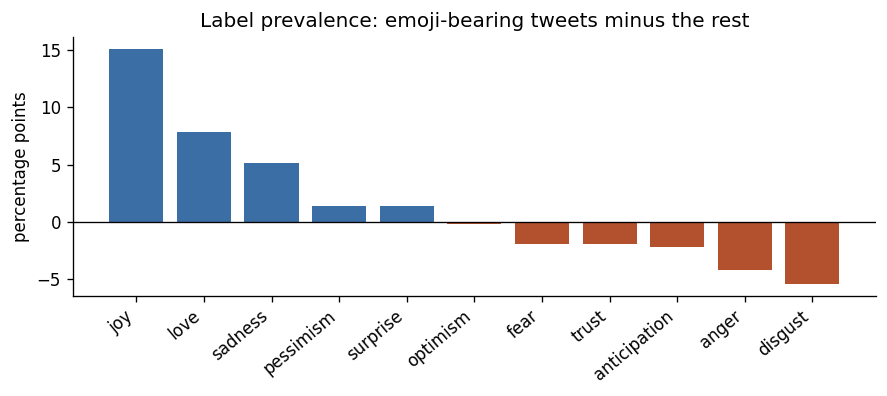

,with emoji,without emoji,difference
joy,49.6,34.5,15.1
love,17.1,9.4,7.8
sadness,33.9,28.8,5.1
pessimism,12.9,11.5,1.4
surprise,6.5,5.1,1.4
optimism,28.8,29.0,-0.2
fear,16.5,18.4,-1.9
trust,3.5,5.4,-1.9
anticipation,12.3,14.6,-2.2
anger,33.5,37.7,-4.2


In [ ]:
with_e = train[train["has_emoji"]][EMOTION_LABELS].mean()
without_e = train[~train["has_emoji"]][EMOTION_LABELS].mean()
comp = (pd.DataFrame({"with emoji": with_e, "without emoji": without_e})
          .assign(difference=lambda d: d["with emoji"] - d["without emoji"])
          .sort_values("difference", ascending=False) * 100).round(1)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(comp.index, comp["difference"],
       color=[BLUE if v > 0 else RUST for v in comp["difference"]])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("percentage points")
ax.set_title("Label prevalence: emoji-bearing tweets minus the rest")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "emoji_label_skew.png")
plt.show()

display(comp)

## Summary of findings

Record the numbers printed above; they are cited directly in the dissertation.

1. **Label imbalance is severe**, so `03` uses a positive-weighted cross-entropy
   objective and tunes a decision threshold per condition rather than assuming 0.5.
2. **The task is genuinely multi-label**, so evaluation uses Micro-F1 and Macro-F1
   with per-label thresholds, not plain accuracy.
3. **Mentions are common and URLs are effectively absent**, so mention stripping is
   the preprocessing stage that does real work — and it doubles as de-identification.
4. **Only a minority of tweets contain emoji**, which caps the achievable aggregate
   effect and is the single most important caveat on the study's headline numbers.